<a href="https://colab.research.google.com/github/Luisa-Enriquez/VIC2025/blob/main/copia_de_breastcancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Descargar y descomprimir dataset BreakHis
!wget -nc http://www.inf.ufpr.br/vri/databases/BreaKHis_v1.tar.gz
!tar -xvzf BreaKHis_v1.tar.gz

# Verificar carpetas base
!ls BreaKHis_v1/histology_slides/breast

import os
import shutil
from glob import glob

# Ruta base del dataset descomprimido
original_path = '/content/BreaKHis_v1/histology_slides/breast/'
target_path = '/content/breakhis_imagefolder/'

# Crear carpetas destino para ImageFolder
os.makedirs(os.path.join(target_path, 'benign'), exist_ok=True)
os.makedirs(os.path.join(target_path, 'malignant'), exist_ok=True)

# Copiar imágenes
def copiar_imagenes():
    for clase in ['benign', 'malignant']:
        # recorrer hasta 6 niveles (incluye magnificación)
        patron = os.path.join(original_path, clase, 'SOB', '*', '*', '*', '*.png')
        imagenes = glob(patron)
        print(f"🔎 Copiando {len(imagenes)} imágenes de clase '{clase}'")
        for ruta_img in imagenes:
            nombre_archivo = os.path.basename(ruta_img)
            destino = os.path.join(target_path, clase, nombre_archivo)
            shutil.copyfile(ruta_img, destino)

copiar_imagenes()
print("✅ Imágenes copiadas correctamente al formato ImageFolder")

Se han truncado las últimas 5000 líneas del flujo de salida.
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-15572/40X/SOB_M_DC-14-15572-40-021.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-14946/40X/SOB_M_DC-14-14946-40-029.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-16716/400X/SOB_M_DC-14-16716-400-030.png
BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549AB/400X/SOB_B_A-14-22549AB-400-021.png
BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549G/100X/SOB_B_A-14-22549G-100-025.png
BreaKHis_v1/histology_slides/breast/benign/SOB/tubular_adenoma/SOB_B_TA_14-13200/200X/SOB_B_TA-14-13200-200-012.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-3909/200X/SOB_M_DC-14-3909-200-016.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-20636/200X/SOB_M_DC-14-20636-200-009.png
BreaKHis_

In [ ]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()
dataset = datasets.ImageFolder(root="/content/breakhis_imagefolder", transform=transform)
print("Clases:", dataset.classes)
print("Total de imágenes:", len(dataset))


FileNotFoundError: [Errno 2] No such file or directory: '/content/breakhis_imagefolder'

In [ ]:
# Copiar dataset completo a Google Drive
drive_dest = '/content/drive/MyDrive/breakhis_imagefolder'

import os
import shutil

# Copiar dataset completo a Google Drive
target_dir = '/content/breakhis_imagefolder'  # Ruta origen del dataset
drive_dest = '/content/drive/MyDrive/breakhis_imagefolder'  # Ruta destino en Google Drive
# Borrar carpeta destino si existe para evitar conflicto
if os.path.exists(drive_dest):
    shutil.rmtree(drive_dest)

shutil.copytree(target_dir, drive_dest)
print(f"✅ Dataset copiado exitosamente a: {drive_dest}")

# CONFIGURACIÓN
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# PARÁMETROS
drive_dest = '/content/drive/MyDrive/breakhis_imagefolder'
batch_size = 16
num_epochs = 35
num_classes = 2
learning_rate = 1e-4

# TRANSFORMACIONES
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

✅ Dataset copiado exitosamente a: /content/drive/MyDrive/breakhis_imagefolder
Usando dispositivo: cuda


In [ ]:
# CARGA DEL DATASET
full_dataset = datasets.ImageFolder(root=drive_dest, transform=train_transform)
class_names = full_dataset.classes
print("Clases detectadas:", class_names)
print(f"Total imágenes: {len(full_dataset)}")

Clases detectadas: ['benign', 'malignant']
Total imágenes: 7909


In [ ]:
from collections import Counter
import numpy as np

labels = [label for _, label in full_dataset.samples]
count = Counter(labels)
total = sum(count.values())
for k, v in count.items():
    print(f"Clase {full_dataset.classes[k]}: {v} imágenes ({100 * v / total:.2f}%)")


Clase benign: 2480 imágenes (31.36%)
Clase malignant: 5429 imágenes (68.64%)


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, WeightedRandomSampler
import torch

# Obtener etiquetas e índices del dataset completo
targets = [label for _, label in full_dataset.samples]
indices = list(range(len(full_dataset)))

# División estratificada: 70% train, 15% val, 15% test
train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, targets, test_size=0.3, stratify=targets, random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
)

# Crear subconjuntos con Subset
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

# Asignar transformaciones
full_dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# Crear sampler balanceado para entrenamiento
# Recolectar etiquetas de train
train_targets = [targets[i] for i in train_idx]
class_sample_counts = torch.tensor([train_targets.count(0), train_targets.count(1)], dtype=torch.float)
weights_per_class = 1.0 / class_sample_counts
sample_weights = torch.tensor([weights_per_class[label] for label in train_targets])
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Verificar tamaños
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")



# FUNCIÓN DE MODELOS
from torchvision import models
from torchvision.models import (
    DenseNet121_Weights,
    ResNet50_Weights,
    MobileNet_V2_Weights,
    VGG16_Weights,
    ConvNeXt_Tiny_Weights,
    EfficientNet_B0_Weights,
)

def crear_modelo(nombre_modelo='densenet121', num_clases=2, pretrained=True):
    nombre_modelo = nombre_modelo.lower()

    if nombre_modelo == 'resnet50':
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_clases)

    elif nombre_modelo == 'mobilenet_v2':
        weights = MobileNet_V2_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v2(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_clases)

    elif nombre_modelo == 'vgg16':
        weights = VGG16_Weights.DEFAULT if pretrained else None
        model = models.vgg16(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_clases)

    elif nombre_modelo == 'convnext_tiny':
        weights = ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        model = models.convnext_tiny(weights=weights)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_clases)

    elif nombre_modelo == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_clases)

    elif nombre_modelo == 'densenet121':
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_clases)

    else:
        raise ValueError(f"Modelo '{nombre_modelo}' no soportado.")

    return model


Train samples: 5536, Validation samples: 1186, Test samples: 1187


In [ ]:
# MODELO Y ENTRENAMIENTO

# Crear el modelo
model = crear_modelo('densenet121', num_clases=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Inicializar métricas y early stopping
train_losses, val_losses, val_accuracies = [], [], []

class EarlyStopping:
    def __init__(self, patience=7, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.best_model = model.state_dict()
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f"📉 EarlyStopping: sin mejora en {self.counter} épocas")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model = model.state_dict()
            self.counter = 0

early_stopper = EarlyStopping(patience=7)

from sklearn.metrics import f1_score

best_f1 = 0.0
best_model_path = "/content/drive/MyDrive/best_model_breakhis.pt"

# Entrenamiento por épocas
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Época {epoch+1}/{num_epochs}")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDACIÓN
    model.eval()
    correct, total = 0, 0
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(acc)
    scheduler.step()

    # Calcular F1-score macro
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    print(f"\n✅ Época {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {acc:.4f}, F1: {f1_macro:.4f}")

    # Guardar mejor modelo (según F1)
    if f1_macro > best_f1:
        best_f1 = f1_macro
        torch.save(model.state_dict(), best_model_path)
        print(f"📦 Nuevo mejor modelo guardado (F1={f1_macro:.4f})")

    # Early Stopping
    early_stopper(val_loss, model)
    if early_stopper.early_stop:
        print("🛑 Early stopping activado.")
        break

# Restaurar el mejor modelo
model.load_state_dict(torch.load(best_model_path))
print("✅ Mejor modelo restaurado desde disco (validación F1-score máximo).")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 140MB/s]
Época 1/35: 100%|██████████| 346/346 [02:18<00:00,  2.50it/s, loss=0.103]



✅ Época 1 - Train Loss: 0.2146, Val Loss: 9.2442, Val Acc: 0.9477, F1: 0.9396
📦 Nuevo mejor modelo guardado (F1=0.9396)


Época 2/35: 100%|██████████| 346/346 [01:52<00:00,  3.08it/s, loss=0.00565]



✅ Época 2 - Train Loss: 0.1115, Val Loss: 8.3113, Val Acc: 0.9604, F1: 0.9550
📦 Nuevo mejor modelo guardado (F1=0.9550)


Época 3/35: 100%|██████████| 346/346 [01:49<00:00,  3.15it/s, loss=0.00688]


...


✅ Época 26 - Train Loss: 0.0019, Val Loss: 3.3377, Val Acc: 0.9882, F1: 0.9863
📉 EarlyStopping: sin mejora en 5 épocas


Época 27/35: 100%|██████████| 346/346 [01:41<00:00,  3.41it/s, loss=0.000223]



✅ Época 27 - Train Loss: 0.0039, Val Loss: 3.3841, Val Acc: 0.9874, F1: 0.9853
📉 EarlyStopping: sin mejora en 6 épocas


Época 28/35: 100%|██████████| 346/346 [01:42<00:00,  3.38it/s, loss=0.00178]



✅ Época 28 - Train Loss: 0.0020, Val Loss: 3.2583, Val Acc: 0.9874, F1: 0.9853
📉 EarlyStopping: sin mejora en 7 épocas
🛑 Early stopping activado.
✅ Mejor modelo restaurado desde disco (validación F1-score máximo).


In [ ]:
import pickle

history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies
}

with open('/content/drive/MyDrive/train_history.pkl', 'wb') as f:
    pickle.dump(history, f)


In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 108.0 MB/s eta 0:00:00


In [ ]:
# EXPORTAR A ONNX
dummy_input = torch.randn(1, 3, 224, 224).to(device)
onnx_path = "/content/drive/MyDrive/best_model_breakhis.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    opset_version=11,
    export_params=True,
    do_constant_folding=True
)

print(f"✅ Modelo exportado a ONNX: {onnx_path}")

✅ Modelo exportado a ONNX: /content/drive/MyDrive/best_model_breakhis.onnx


In [ ]:
import matplotlib.pyplot as plt
# CURVAS DE ENTRENAMIENTO Y VALIDACIÓN
plt.figure(figsize=(12, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida")
plt.legend()
plt.grid(True)

# Precisión
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', marker='o', color='green')
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Precisión en Validación")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



📊 Evaluación en TEST:
              precision    recall  f1-score   support

      benign       0.98      0.98      0.98       372
   malignant       0.99      0.99      0.99       815

    accuracy                           0.99      1187
   macro avg       0.99      0.98      0.99      1187
weighted avg       0.99      0.99      0.99      1187

F1-score macro (TEST): 0.985285768474604


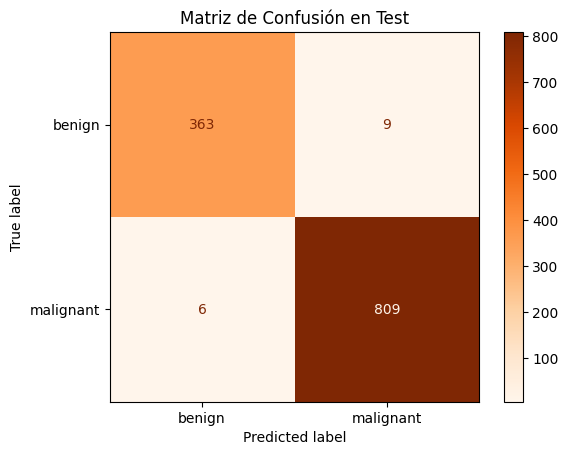

In [ ]:
# EVALUACIÓN EN TEST
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Reporte
print("\n📊 Evaluación en TEST:")
print(classification_report(test_labels, test_preds, target_names=class_names))
print("F1-score macro (TEST):", f1_score(test_labels, test_preds, average='macro'))

# Matriz de confusión en test
cm_test = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(cmap=plt.cm.Oranges)
plt.title("Matriz de Confusión en Test")
plt.show()


In [ ]:
import torch.nn.functional as F

def mostrar_predicciones_test(dataloader, modelo, class_names, device, num_imagenes=5):
    modelo.eval()
    inputs, labels = next(iter(dataloader))  # Obtener un batch del test
    inputs, labels = inputs[:num_imagenes], labels[:num_imagenes]
    inputs, labels = inputs.to(device), labels.to(device)

    with torch.no_grad():
        outputs = modelo(inputs)
        probs = F.softmax(outputs, dim=1)  # Obtener probabilidades
        confs, preds = torch.max(probs, 1)

    inputs = inputs.cpu().numpy()
    confs = confs.cpu().numpy()
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()

    # Visualizar
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, num_imagenes, figsize=(16, 4))
    for i in range(num_imagenes):
        img = np.transpose(inputs[i], (1, 2, 0))  # De CxHxW a HxWxC
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Desnormalizar
        img = np.clip(img, 0, 1)

        ax = axes[i]
        ax.imshow(img)
        gt = class_names[labels[i]]
        pred = class_names[preds[i]]
        conf = confs[i] * 100
        color = 'green' if pred == gt else 'red'
        ax.set_title(f"GT: {gt}\nPred: {pred}\nConf: {conf:.1f}%", color=color)
        ax.axis('off')

    plt.suptitle("Predicciones visuales en conjunto de prueba (test)")
    plt.tight_layout()
    plt.show()


In [ ]:
mostrar_predicciones_test(test_loader, model, class_names, device)


In [ ]:
# Instalar onnx y onnx-tf (si no lo tienes)
!pip install -q onnx onnx-tf tensorflow

# Convertir ONNX a TensorFlow SavedModel
import onnx
from onnx_tf.backend import prepare

onnx_model = onnx.load(onnx_path)
tf_rep = prepare(onnx_model)
tf_rep.export_graph("/content/best_model_tf")

# Convertir a TFLite
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("/content/best_model_tf")
tflite_model = converter.convert()

# Guardar modelo .tflite en Drive
tflite_path = "/content/drive/MyDrive/best_model_breakhis.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Modelo exportado a TFLite: {tflite_path}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 31.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.18.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

ModuleNotFoundError: No module named 'keras.src.engine'

In [ ]:
!ls /content


In [ ]:
import pickle

with open('/content/train_history.pkl', 'rb') as f:
    history = pickle.load(f)

train_losses   = history['train_losses']
val_losses     = history['val_losses']
val_accuracies = history['val_accuracies']


In [ ]:
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


NameError: name 'test_dataset' is not defined

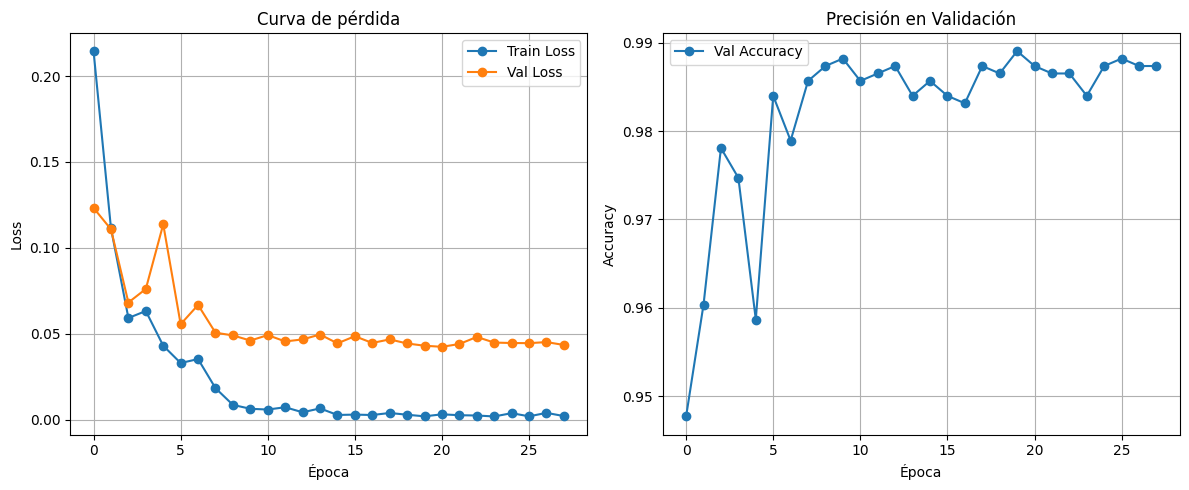

NameError: name 'test_loader' is not defined

In [ ]:
import pickle
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np



train_losses     = history['train_losses']
val_losses       = history['val_losses']
val_accuracies   = history['val_accuracies']

# 2) Plots de pérdida y precisión
plt.figure(figsize=(12, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='o')
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida")
plt.legend()
plt.grid(True)

# Precisión validación
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', marker='o')
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Precisión en Validación")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3) Función para mostrar predicciones en test
def mostrar_predicciones_test(dataloader, modelo, class_names, device, num_imagenes=5):
    modelo.eval()
    inputs, labels = next(iter(dataloader))
    inputs, labels = inputs[:num_imagenes].to(device), labels[:num_imagenes].to(device)

    with torch.no_grad():
        outputs = modelo(inputs)
        probs   = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, 1)

    inputs = inputs.cpu().numpy()
    confs  = confs.cpu().numpy() * 100
    preds  = preds.cpu().numpy()
    labels = labels.cpu().numpy()

    fig, axes = plt.subplots(1, num_imagenes, figsize=(16, 4))
    for i in range(num_imagenes):
        img = np.transpose(inputs[i], (1, 2, 0))
        # desnormalizar
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)

        ax = axes[i]
        ax.imshow(img)
        gt   = class_names[labels[i]]
        pred = class_names[preds[i]]
        color = 'green' if pred == gt else 'red'
        ax.set_title(f"GT: {gt}\nPred: {pred}\nConf: {confs[i]:.1f}%", color=color)
        ax.axis('off')

    plt.suptitle("Predicciones visuales en conjunto de prueba (test)")
    plt.tight_layout()
    plt.show()

# 4) Llamada
mostrar_predicciones_test(test_loader, model, class_names, device)
